# One-Shot Deep ContourFlow (DCF)

Fit the contour model on a **support** image (with a known ground-truth contour), then transfer it to a **query** image — no retraining required.

**Steps:** load support → visualize → fit → load query → initialize contour → predict → visualize evolution

In [1]:
from pathlib import Path
import os
import sys
path_dcf = str(Path(os.path.abspath('.')).resolve().parent)
sys.path.append(path_dcf)
from deep_contourflow import OneShotDCF as DCF
from deep_contourflow.features import define_contour_init
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from torch_contour import CleanContours
from deep_contourflow.visualization import plot_support_with_gt, plot_contour_evolution

height = 512
viz_dir = os.path.join(path_dcf, "visualisations")
os.makedirs(viz_dir, exist_ok=True)

### Load support image and ground truth

Saved → /home/antoine.habis/Deep-ContourFlow/visualisations/support_gt_human1.jpg.png


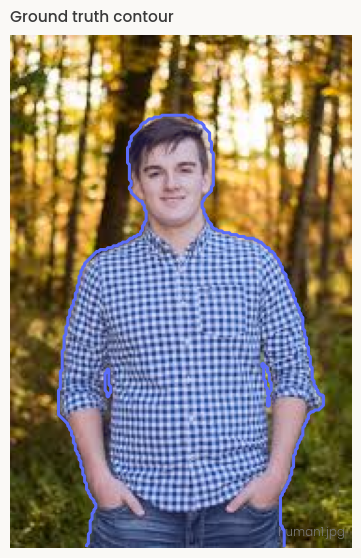

In [2]:
filename_support = "human1.jpg"
img = plt.imread(os.path.join(path_dcf, "data", filename_support)).astype(np.uint8)
gt  = plt.imread(os.path.join(path_dcf, "data", "gt", filename_support.split(".")[-2] + ".png")).astype(np.uint8)

fig = plot_support_with_gt(
    img, gt, filename=filename_support,
    save_path=os.path.join(viz_dir, f"support_gt_{filename_support}.png"),
)
plt.show()

### Instantiate the one-shot DCF model

In [3]:
dcf = DCF(
    n_epochs=200,                    # max gradient steps
    nb_augment=100,                  # number of augmented support views at fit time
    learning_rate=1e-2,              # gradient step size
    clip=1.0,                        # max contour displacement per step (normalized)
    sigma=1.0,                       # Gaussian smoothing strength on the gradient
    lambda_area=1e-3,                # weight of the area regularization term
    augmentations=["rot90", "vflip"],
    exponential_decay=0.999,         # learning rate decay per epoch
    thresh=1e-5,
    early_stopping_patience=100,
    early_stopping_threshold=1e-4,
    do_apply_grabcut=False,
)

INFO:deep_contourflow.oneshot:DCF initialized with 200 epochs, lr=0.01, device=cuda


### Fit on the support image

In [4]:
img_support = cv2.resize(img, (height, height), interpolation=cv2.INTER_AREA).astype(np.uint8)
gt_support = cv2.resize(gt, (height, height), interpolation=cv2.INTER_AREA).astype(np.uint8)
# Use gt_support (resized to height×height) so contour coords stay in [0, 1] after /height
contours = np.squeeze(cv2.findContours(gt_support, 1, 3)[0][-1]) / height
c = CleanContours()
contour_support = c.interpolate(contours, 100).clip(0, 1)
contour_support = torch.tensor(contour_support, dtype=torch.float32)[None, None]
tensor_support = torch.tensor(np.moveaxis(img_support, -1, 0)[None]) / 255

In [5]:
dcf.fit(tensor_support, contour_support)

INFO:deep_contourflow.oneshot:Fitting DCF one shot...
Augmenting support: 100%|██████████| 100/100 [00:03<00:00, 33.08it/s]
INFO:deep_contourflow.oneshot:DCF fitting completed successfully


### Load query image and initialize contour

In [6]:
filename_query = "human2.jpg"
img_query = plt.imread(os.path.join(path_dcf,"data", filename_query)).astype(np.uint8)
img_query = cv2.resize(img_query, (height, height), interpolation=cv2.INTER_AREA).astype(np.uint8)
tensor_query = torch.tensor(np.moveaxis(img_query, -1, 0)[None]) / 255

In [7]:
contour_init, mask = define_contour_init(height, shape="circle", size=0.9)
# size=0.9 → radius = 90% of min(height, width), centered by default
# contour_init is already in [0, 1]

nb_nodes = 100
c = CleanContours()
contour_init = c.interpolate(contour_init, nb_nodes).clip(0, 1)
contour_init = torch.tensor(contour_init, dtype=torch.float32)[None, None]

### Predict and visualize contour evolution

INFO:deep_contourflow.oneshot:Contour is evolving please wait a few moments...
Evolving contour: 100%|██████████| 200/200 [00:00<00:00, 238.55it/s]
INFO:deep_contourflow.oneshot:Prediction completed successfully
/home/antoine.habis/Deep-ContourFlow/deep_contourflow/visualization.py:290: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.4)


Saved → /home/antoine.habis/Deep-ContourFlow/visualisations/contour_evolution_human2.jpg.png


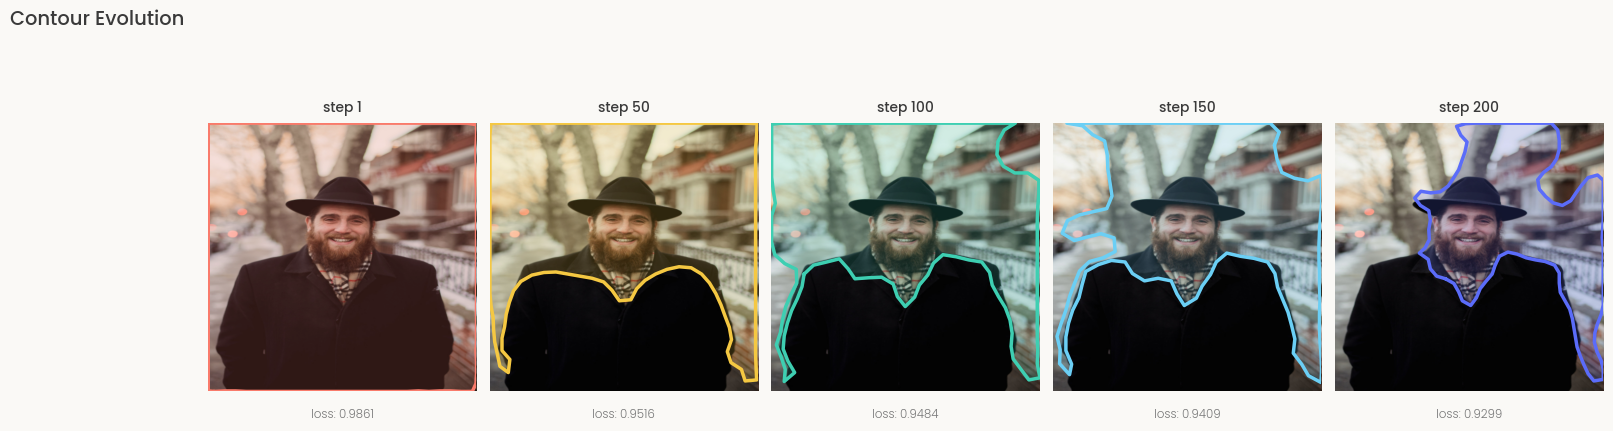

In [8]:
contours, score, tots, energies = dcf.predict(tensor_query, contour_init)

fig = plot_contour_evolution(
    img_query, dcf.contour_history_, tots,
    save_path=os.path.join(viz_dir, f"contour_evolution_{filename_query}.png"),
)
plt.show()